In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch

# Import library for Kendall correlation
import scipy.stats as stats
from statsmodels.stats.multitest import fdrcorrection

# Import mutual information regression library from scikit-learn
from sklearn.feature_selection import mutual_info_regression

from transformers import AutoTokenizer, AutoModelForCausalLM, logging

logging.set_verbosity_error()

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# Import model
model_name = "gpt2-xl"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

num_layers = model.config.n_layer

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1600)
    (wpe): Embedding(1024, 1600)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-47): 48 x GPT2Block(
        (ln_1): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=4800, nx=1600)
          (c_proj): Conv1D(nf=1600, nx=1600)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=6400, nx=1600)
          (c_proj): Conv1D(nf=1600, nx=6400)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1600,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1600, out_features=50257, bias=False)
)

# Implant hooks at the expanded attention and mlp layers

In [4]:
# Function for hook
activations = {}
def implant_hook(layer):
    def hook(module, input, output):
        # 'output' from GPT2Attention can be a tuple (output_tensor, attention_weights)
        # We want the output_tensor, which is the first element.
        if isinstance(output, tuple):
            output_tensor = output[0]
        else:
            output_tensor = output

        if module == model.transformer.h[layer].attn.c_proj:
            activations[f'attn_proj_{layer}'] = output_tensor.detach()
        else:
            activations[f'mlp_proj_{layer}'] = output_tensor.detach()
        return None
    return hook

In [5]:
if 'hook_handles' in globals():
  for h in hook_handles:
    h.remove()

hook_handles = []

for layer in range(num_layers):
  hook_handles.append(model.transformer.h[layer].attn.c_proj.register_forward_hook(implant_hook(layer)))
  hook_handles.append(model.transformer.h[layer].mlp.c_proj.register_forward_hook(implant_hook(layer)))

In [6]:
# test
text = "I love coding in Python"
token_ids = tokenizer(text, return_tensors='pt').to(device)

with torch.no_grad(): model(**token_ids)

In [7]:
activations.keys()

dict_keys(['attn_proj_0', 'mlp_proj_0', 'attn_proj_1', 'mlp_proj_1', 'attn_proj_2', 'mlp_proj_2', 'attn_proj_3', 'mlp_proj_3', 'attn_proj_4', 'mlp_proj_4', 'attn_proj_5', 'mlp_proj_5', 'attn_proj_6', 'mlp_proj_6', 'attn_proj_7', 'mlp_proj_7', 'attn_proj_8', 'mlp_proj_8', 'attn_proj_9', 'mlp_proj_9', 'attn_proj_10', 'mlp_proj_10', 'attn_proj_11', 'mlp_proj_11', 'attn_proj_12', 'mlp_proj_12', 'attn_proj_13', 'mlp_proj_13', 'attn_proj_14', 'mlp_proj_14', 'attn_proj_15', 'mlp_proj_15', 'attn_proj_16', 'mlp_proj_16', 'attn_proj_17', 'mlp_proj_17', 'attn_proj_18', 'mlp_proj_18', 'attn_proj_19', 'mlp_proj_19', 'attn_proj_20', 'mlp_proj_20', 'attn_proj_21', 'mlp_proj_21', 'attn_proj_22', 'mlp_proj_22', 'attn_proj_23', 'mlp_proj_23', 'attn_proj_24', 'mlp_proj_24', 'attn_proj_25', 'mlp_proj_25', 'attn_proj_26', 'mlp_proj_26', 'attn_proj_27', 'mlp_proj_27', 'attn_proj_28', 'mlp_proj_28', 'attn_proj_29', 'mlp_proj_29', 'attn_proj_30', 'mlp_proj_30', 'attn_proj_31', 'mlp_proj_31', 'attn_proj_32', '

# Import text

In [8]:
# from https://en.wikipedia.org/wiki/Turkish_coffee
text = 'Turkish coffee is very finely ground coffee brewed by boiling. Any coffee bean may be used; arabica varieties are considered best, but robusta or a blend is also used.[1] The coffee grounds are left in the coffee when served.[2][3] The coffee may be ground at home in a manual grinder made for the very fine grind, ground to order by coffee merchants in most parts of the world, or bought ready-ground from many shops.'
tokens = tokenizer.encode(text,return_tensors='pt')
print(f'There are {len(tokens[0])} tokens, {len(set(tokens[0].tolist()))} of which are unique.')

There are 94 tokens, 67 of which are unique.


In [9]:
target_word = ' coffee'
target_token_id = tokenizer.encode(target_word, return_tensors='pt').item()
target_idxs = torch.where(tokens == target_token_id)[1]
target_idxs

tensor([ 1,  6, 12, 39, 45, 54, 76])

In [10]:
# forward pass the tokens through the model
with torch.no_grad(): model(tokens.to(device), return_hidden_states=True)
#

In [11]:
activations['attn_proj_0'].shape

torch.Size([1, 94, 1600])

# Trimmed MI function

In [18]:
# a function for mutual information
def mutInfo(x,y,outlierThresh=0):

  # remove outliers based on a z-score threshold
  if outlierThresh>0:

    # z-standardize the variables
    zx = (x-x.mean()) / x.std(ddof=1)
    zy = (y-y.mean()) / y.std(ddof=1)

    # remove data points based on threshold exceedances
    outlier = (abs(zx)>outlierThresh) | (abs(zy)>outlierThresh)
    x = x[~outlier]
    y = y[~outlier]


  # histogram and convert to proportion (estimate of probability)
  Z  = np.histogram2d(x,y,bins=15)[0]
  pZ = Z / Z.sum()
  px = pZ.sum(axis=1)
  py = pZ.sum(axis=0)

  # calculate entropy
  eps = 1e-12
  Hx = -np.sum( px * np.log2(px+eps) )
  Hy = -np.sum( py * np.log2(py+eps) )
  HZ = -np.sum( pZ * np.log2(pZ+eps) )

  return Hx+Hy - HZ

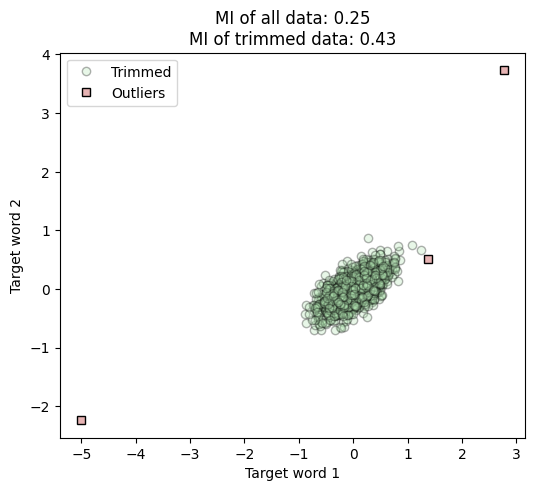

In [13]:
# extract some data
x = activations['attn_proj_3'][0,target_idxs[0],:].cpu().numpy()
y = activations['attn_proj_3'][0,target_idxs[1],:].cpu().numpy()

# z-transform
zx = (x-x.mean()) / x.std(ddof=1)
zy = (y-y.mean()) / y.std(ddof=1)

# identify outliers
threshold = 4
outlier = (abs(zx)>threshold) | (abs(zy)>threshold)

# mutual information with and without
miAll  = mutInfo(x,y)
miTrim = mutInfo(x,y,outlierThresh=threshold) # trimmed

miSkAll = mutual_info_regression(x.reshape(-1,1),y)[0]
miSkTrim = mutual_info_regression(x[~outlier].reshape(-1,1),y[~outlier])[0]

# plot
plt.figure(figsize=(6,5))
plt.plot(x[~outlier],y[~outlier],'ko',markerfacecolor=[.7,.9,.7,.3],label='Trimmed')
plt.plot(x[outlier],y[outlier],'ks',markerfacecolor=[.9,.7,.7],label='Outliers')
plt.gca().set(xlabel='Target word 1',ylabel='Target word 2')

plt.title(f'MI of all data: {miAll:.2f}\nMI of trimmed data: {miTrim:.2f}')

plt.legend()
plt.show()

In [14]:
# comparisons
print(f'Manual, all data : {miAll:.3f}')
print(f'Manual, trimmed  : {miTrim:.3f}')
print(f'Difference:      : {miAll-miTrim:.3f}\n')

print(f'Sklearn, all data: {miSkAll:.3f}')
print(f'Sklearn, trimmed : {miSkTrim:.3f}')
print(f'Difference:      : {miSkAll-miSkTrim:.3f}')

Manual, all data : 0.245
Manual, trimmed  : 0.434
Difference:      : -0.189

Sklearn, all data: 0.288
Sklearn, trimmed : 0.287
Difference:      : 0.002


# MI and token distances in one layer

In [31]:
mi = np.zeros((len(target_idxs),len(target_idxs)))
tokdists = np.zeros((len(target_idxs),len(target_idxs)))

# double-loop over the word pairs
for toki in range(len(target_idxs)):
  for tokj in range(toki+1,len(target_idxs)):

    # extract the data
    x = activations['attn_proj_3'][0,target_idxs[toki],:].cpu().numpy()
    y = activations['attn_proj_3'][0,target_idxs[tokj],:].cpu().numpy()

    # pairwise mutual information
    mi[toki,tokj] = mutInfo(x,y,4)
    tokdists[toki,tokj] = target_idxs[tokj]-target_idxs[toki]

    # mi[toki,tokj] = mutual_info_regression(x.reshape(-1,1),y)[0]

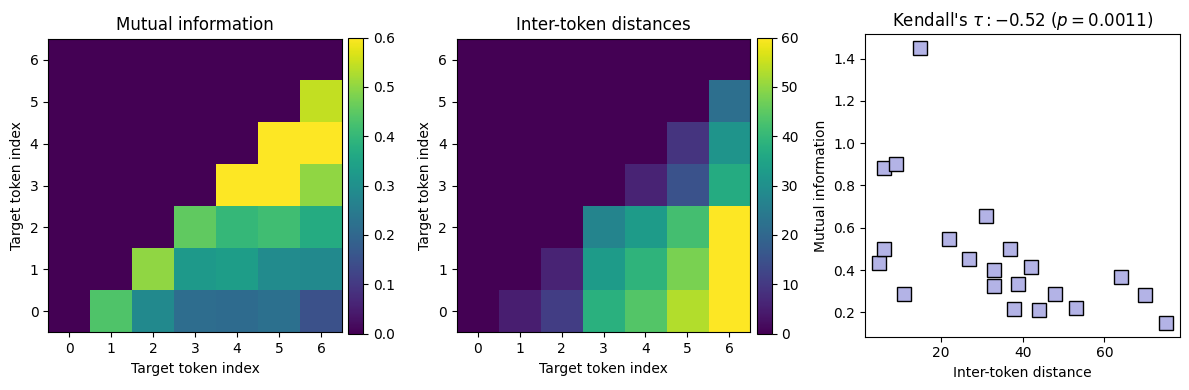

In [32]:
fig,axs = plt.subplots(1,3,figsize=(12,4))

h = axs[0].imshow(mi,origin='lower',vmin=0,vmax=.6)
axs[0].set(xlabel='Target token index',ylabel='Target token index',title='Mutual information')
fig.colorbar(h,ax=axs[0],pad=.02,fraction=.047)

# distances
h = axs[1].imshow(tokdists,origin='lower',vmin=0,vmax=60)
axs[1].set(xlabel='Target token index',ylabel='Target token index',title='Inter-token distances')
fig.colorbar(h,ax=axs[1],pad=.02,fraction=.047)

# correlate MI with token distance
r = stats.kendalltau(tokdists[np.nonzero(tokdists)],mi[np.nonzero(mi)])

axs[2].plot(tokdists[np.nonzero(tokdists)],mi[np.nonzero(mi)],'ks',markersize=10,markerfacecolor=[.7,.7,.9])
axs[2].set(xlabel='Inter-token distance',ylabel='Mutual information',
           title=f"Kendall's $\\tau: {r.statistic:.2f}$ ($p={r.pvalue:.4f}$)")

plt.tight_layout()
plt.show()

# MI metrics over layers

In [35]:
MIresults = np.zeros((2,num_layers,2))

# initialize temp matrices (overwritten in each layer)
miA = np.zeros((len(target_idxs),len(target_idxs)))
miM = np.zeros((len(target_idxs),len(target_idxs)))

sublayerComps = np.zeros((num_layers,2,2))



# loop over layers
for layeri in range(num_layers):


  # double-loop over the word pairs
  for toki in range(len(target_idxs)):
    for tokj in range(toki+1,len(target_idxs)):

      ### ATTENTION block
      # extract the data
      x = activations[f'attn_proj_{layeri}'][0,target_idxs[toki],:].cpu().numpy()
      y = activations[f'attn_proj_{layeri}'][0,target_idxs[tokj],:].cpu().numpy()

      # trimmed manual MI implementation
      miA[toki,tokj] = mutInfo(x,y,4)

      # Exercise 5: pairwise mutual information using sklearn
      # miA[toki,tokj] = mutual_info_regression(x.reshape(-1,1),y)[0]


      ### MLP block
      # extract the data
      x = activations[f'mlp_proj_{layeri}'][0,target_idxs[toki],:].cpu().numpy()
      y = activations[f'mlp_proj_{layeri}'][0,target_idxs[tokj],:].cpu().numpy()

      # pairwise mutual information (second line is for Exercise 5)
      miM[toki,tokj] = mutInfo(x,y,4)
      # miM[toki,tokj] = mutual_info_regression(x.reshape(-1,1),y)[0]


  # ATTENTION summary statistics
  uMIa = miA[np.triu_indices(miA.shape[0],1)] # (uMIa = unique mutual information attn)
  uDi  = tokdists[np.triu_indices(tokdists.shape[0],1)] # doesn't change for attn-vs-mlp
  MIresults[0,layeri,0] = np.mean(uMIa)
  MIresults[0,layeri,1] = stats.kendalltau(uMIa,uDi).statistic

  # MLP summary statistics
  uMIm = miM[np.triu_indices(miM.shape[0],1)]
  MIresults[1,layeri,0] = np.mean(uMIm)
  MIresults[1,layeri,1] = stats.kendalltau(uMIm,uDi).statistic

  # t-test to compare MI
  t = stats.ttest_ind(uMIm,uMIa)
  sublayerComps[layeri,0,0] = t.statistic
  sublayerComps[layeri,0,1] = t.pvalue

  # z-test to compare correlations
  ra = np.atanh(MIresults[0,layeri,1]) # fisher-transformed correlation
  rm = np.atanh(MIresults[1,layeri,1])
  z = (ra-rm) / np.sqrt( 2/(len(uMIa)-3) ) # diff/ste
  p = stats.norm.cdf(-abs(z)) # p-value

  sublayerComps[layeri,1,0] = z
  sublayerComps[layeri,1,1] = p


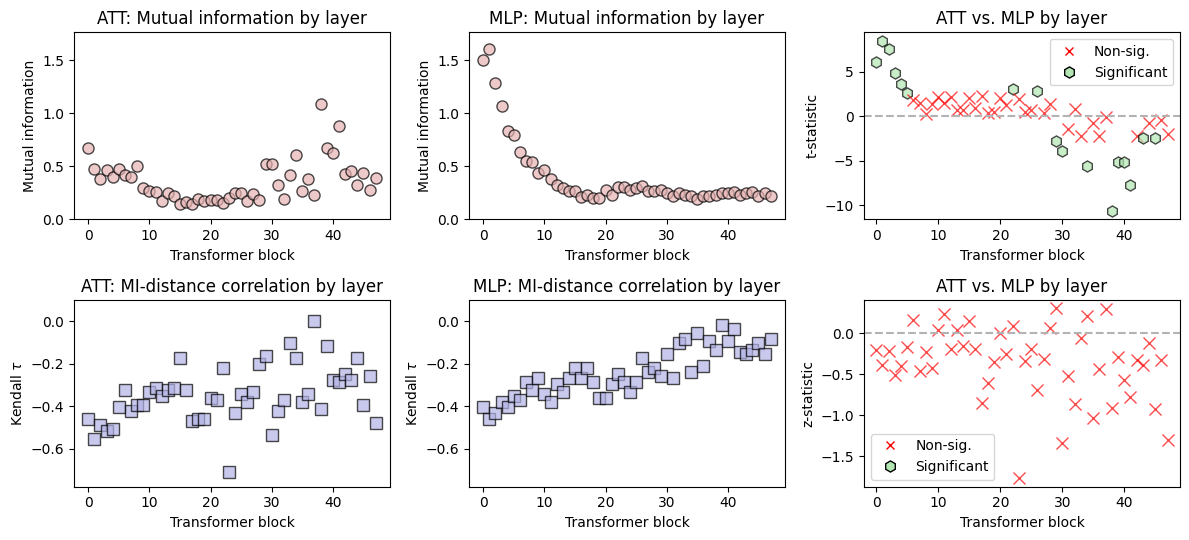

In [37]:
_,axs = plt.subplots(2,3,figsize=(12,5.5))

sublayer_labels = [ 'ATT','MLP' ]

for i in range(2):

  # plot the average MI
  axs[0,i].plot(MIresults[i,:,0],'ko',markerfacecolor=[.9,.7,.7,.7],markersize=8)
  axs[0,i].set(xlabel='Transformer block',ylabel='Mutual information',
               title=f'{sublayer_labels[i]}: Mutual information by layer',
               ylim=[0,MIresults[:,:,0].max()*1.1])

  # plot the MI correlation with token distance
  axs[1,i].plot(MIresults[i,:,1],'ks',markerfacecolor=[.7,.7,.9,.7],markersize=8)
  axs[1,i].set(xlabel='Transformer block',ylabel='Kendall $\\tau$',
               title=f'{sublayer_labels[i]}: MI-distance correlation by layer',
               ylim=[MIresults[:,:,1].min()*1.1,.1])

  # comparing att vs mlp
  fdr_ps = fdrcorrection(sublayerComps[:,i,1])[0]
  for li in range(num_layers):
    marker = 'kh' if fdr_ps[li] else 'rx'
    axs[i,2].plot(li,sublayerComps[li,i,0],marker,markerfacecolor=[.7,.9,.7,.7],markersize=8)

  # legend (kinda hacky)
  axs[i,2].plot(100,0,'rx',label='Non-sig.') # out of bounds
  axs[i,2].plot(100,0,'kh',markerfacecolor=[.7,.9,.7],markersize=8,label='Significant')
  axs[i,2].legend()
  axs[i,2].set(xlim=[-2,num_layers+1],xlabel='Transformer block',ylabel=f"{'tz'[i]}-statistic",title='ATT vs. MLP by layer')
  axs[i,2].axhline(0,linestyle='--',color=[.7,.7,.7])


plt.tight_layout()
plt.show()